In [1]:
# Design of a 100 ns control pulse, parameterized as a Fourier series, to
# implement a pi/2 gate that is robust to amplitude miscalibration and
# frequency detuning.
#
# Robustness is ensured by optimizing over a Transmon.sweep(...) ensemble --
# a grid of (detuning, amplitude-scale) pairs -- to maximize the average gate
# fidelity across the grid, subject to an amplitude constraint.
# Estimated script runtime: ~15 minutes.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, GateTarget, OptimizationProblem, GrapeOptimizer, initial_guess
from grape_scq.bases import symmetric_fourier_basis, antisymmetric_fourier_basis

In [3]:
# Physical system: a robustness grid over amplitude error and detuning
Na, Nd = 5, 5
amp_error = np.linspace(-0.1, 0.1, Na)          # Amplitude error [-10%, 10%]
detuning = 0.2e6 * np.linspace(-1, 1, Nd)       # Detuning [-0.2 MHz, 0.2 MHz]

system = Transmon.sweep(
    frequency=5e9 + detuning,
    amplitude_scale=1 + amp_error,
    anharmonicity=-200e6,
)

target = GateTarget(matrix=np.array([[1, -1j], [-1j, 1]])/np.sqrt(2), subspace=[0, 1])  # pi/2 gate

In [4]:
# Analytic pulse basis (Fourier series)
n_steps = 200
n_coeffs = 5
fx = symmetric_fourier_basis(n_steps, n_coeffs)
fy = antisymmetric_fourier_basis(n_steps, n_coeffs)

problem = OptimizationProblem(system, target, n_steps=n_steps, dt=0.5e-9,
                               reference_amplitude=5e6, ux_basis=fx, uy_basis=fy)

In [5]:
# Initial guess: DRAG-like pulse
pulse0 = initial_guess.cos_drag(problem, theta=np.pi/2)

In [6]:
# Optimize with amplitude constraints
optimizer = GrapeOptimizer(max_iter=2000, max_in_phase=15e6, max_quadrature=15e6)
result = optimizer.optimize(problem, pulse0)

Compiling cost function... Done.
GRAPE optimization result
  cost:      0.004504 -> 0.000524
  fidelity:  0.995496 -> 0.999476
  iterations: 2000
  message:   The maximum number of function evaluations is exceeded.


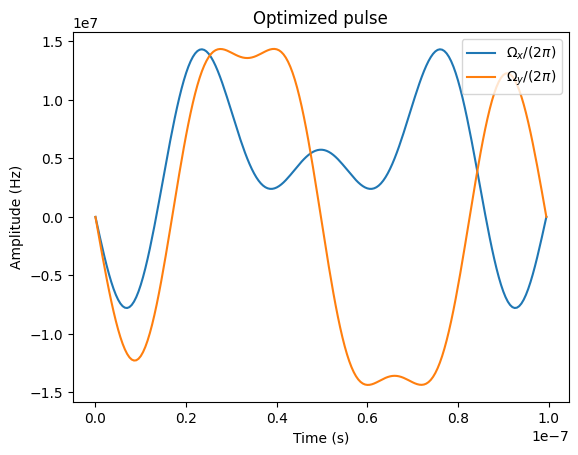

In [7]:
# Display pulse shapes
result.plot_pulse(compare_to_initial=False)
plt.show()

In [8]:
# Extend the grid for a finer fidelity map, and re-evaluate the SAME pulse on it
fine_system = Transmon.sweep(
    frequency=5e9 + 0.65e6*np.linspace(-1, 1, 35),
    amplitude_scale=1 + 0.2*np.linspace(-1, 1, 35),
    anharmonicity=-200e6,
)
fine_problem = problem.with_system(fine_system)

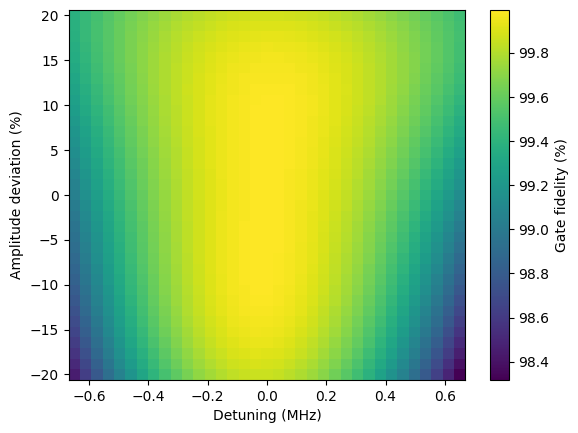

In [9]:
# Display the fidelity map on the fine grid
from grape_scq import analysis
fmap = analysis.fidelity_map(fine_problem, result.pulse).reshape(fine_system.grid_shape)
plt.pcolormesh(fine_system.grid_axes["frequency"]/1e6 - 5e3,
               (fine_system.grid_axes["amplitude_scale"]-1)*100,
               fmap.T*100, shading='auto')
plt.colorbar(label='Gate fidelity (%)')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Amplitude deviation (%)')
plt.show()